Since this is a time-series prediction task, a chronological split was used instead of random sampling. The first 70% of the data was used for training, and the remaining 30% was used for testing to avoid data leakage from future observations.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("cleaned_air_quality_final.csv")

df = df.drop(columns=["AQI_Category"], errors="ignore")

def time_split(df, target_col):
    split_idx = int(len(df) * 0.7)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]

    X_train = train.drop(columns=[target_col])
    y_train = train[target_col]
    X_test = test.drop(columns=[target_col])
    y_test = test[target_col]

    return X_train, X_test, y_train, y_test


def correlation_filter(X, y, threshold=0.05):
    corr = X.corrwith(y).abs()
    selected = corr[corr > threshold].index.tolist()
    print("Correlation selected:", selected)
    return X[selected]


def vif_filter(X, threshold=10):
    X = X.copy()

    while True:
        vif = pd.DataFrame()
        vif["feature"] = X.columns
        vif["VIF"] = [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]

        max_vif = vif["VIF"].max()

        if max_vif > threshold:
            drop_feature = vif.sort_values("VIF", ascending=False)["feature"].iloc[0]
            print(f"Dropping {drop_feature} (VIF={max_vif:.2f})")
            X = X.drop(columns=[drop_feature])
        else:
            break

    return X

def get_models():
    return {
        "Linear Regression": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearRegression())
            ]),
            {}
        ),

        "Decision Tree": (
            DecisionTreeRegressor(),
            {"max_depth": [3, 5, 10, None]}
        ),

        "Random Forest": (
            RandomForestRegressor(),
            {"n_estimators": [50, 100], "max_depth": [5, 10, None]}
        ),

        "KNN": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsRegressor())
            ]),
            {
                "model__n_neighbors": [3, 5, 7]
            }
        )
    }


def run_pipeline(df_city, city_name):
    print(f"\n===== {city_name} =====")

    df_city = df_city.sort_values("Date")

    df_city = df_city.drop(columns=["Date", "City"])

    target_col = "Target_AQI"

    X_train, X_test, y_train, y_test = time_split(df_city, target_col)

    non_numeric = X_train.select_dtypes(include='object').columns
    print("Dropping non-numeric columns:", non_numeric)

    X_train = X_train.drop(columns=non_numeric)
    X_test = X_test.drop(columns=non_numeric)

    y_pred_persist = X_test["AQI"]

    print("\n--- Baselines ---")
    
    print("Persistence R2:", r2_score(y_test, y_pred_persist))
    print("Persistence MAE:", mean_absolute_error(y_test, y_pred_persist))

    X_train_corr = correlation_filter(X_train, y_train)
    X_test_corr = X_test[X_train_corr.columns]

    plt.figure(figsize=(8, 6))
    sns.heatmap(X_train_corr.corr(), cmap="coolwarm")
    plt.title(f"{city_name} Correlation Heatmap")
    plt.show()

    X_train_vif = vif_filter(X_train_corr)
    X_test_vif = X_test_corr[X_train_vif.columns]

    vif_data = pd.DataFrame()
    vif_data["feature"] = X_train_vif.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_train_vif.values, i)
        for i in range(X_train_vif.shape[1])
    ]

    plt.figure()
    plt.barh(vif_data["feature"], vif_data["VIF"])
    plt.title(f"{city_name} VIF")
    plt.show()

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train_vif, y_train)

    importances = pd.Series(rf.feature_importances_, index=X_train_vif.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure()
    importances.plot(kind="bar")
    plt.title(f"{city_name} Feature Importance")
    plt.show()

    top_k = 8
    selected = importances.head(top_k).index.tolist()

    X_train_final = X_train_vif[selected]
    X_test_final = X_test_vif[selected]
    print("\nFinal selected features:", selected)

    models = get_models()
    results = []

    for name, (model, params) in models.items():
        print(f"\n--- {name} ---")

        if params:
            grid = GridSearchCV(model, params, cv=5, scoring="r2")
            grid.fit(X_train_final, y_train)
            best_model = grid.best_estimator_
            print("Best Params:", grid.best_params_)
            print("CV Score:", grid.best_score_)
        else:
            best_model = model.fit(X_train_final, y_train)

        y_pred = best_model.predict(X_test_final)

        plt.figure()
        plt.plot(y_test.values[:100], label="Actual")
        plt.plot(y_pred[:100], label="Predicted")
        plt.legend()
        plt.title(f"{city_name} - {name} Prediction vs Actual")
        plt.show()
        
        residuals = y_test - y_pred
        plt.figure()
        plt.scatter(y_pred, residuals)
        plt.axhline(0)
        plt.title(f"{city_name} - {name} Residual Plot")
        plt.show()

        results.append({
            "City": city_name,
            "Model": name,
            "R2": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred)
        })

    results.append({
    "City": city_name,
    "Model": "Baseline (Persistence)",
    "R2": r2_score(y_test, y_pred_persist),
    "MAE": mean_absolute_error(y_test, y_pred_persist)
})
    
    return pd.DataFrame(results)




===== Atlanta =====
Dropping non-numeric columns: Index(['AQI_Class', 'Season', 'Is_Weekend'], dtype='str')

--- Baselines ---
Persistence R2: 0.2115416536411565
Persistence MAE: 10.790983606557377
Correlation selected: ['NO2', 'O3', 'CO', 'PM2.5', 'AQI', 'Month', 'Wind_Speed', 'Precip', 'Temp', 'AQI_Lag1', 'AQI_7Day_Mean', 'Precip_Lag1', 'Precip_7Day_Mean', 'Is_Weekend_Numeric']


/var/folders/_h/w49ngcjj3251yjmj0qs76q3w0000gp/T/ipykernel_13314/3627925198.py:107: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = X_train.select_dtypes(include='object').columns


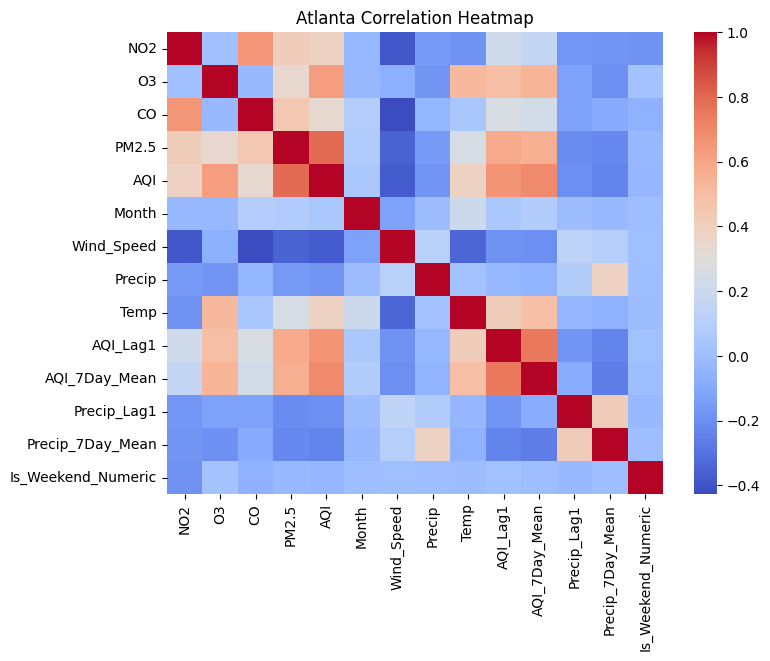

Dropping AQI (VIF=30.37)
Dropping AQI_7Day_Mean (VIF=26.66)
Dropping Temp (VIF=20.45)
Dropping AQI_Lag1 (VIF=10.33)
Dropping CO (VIF=10.17)


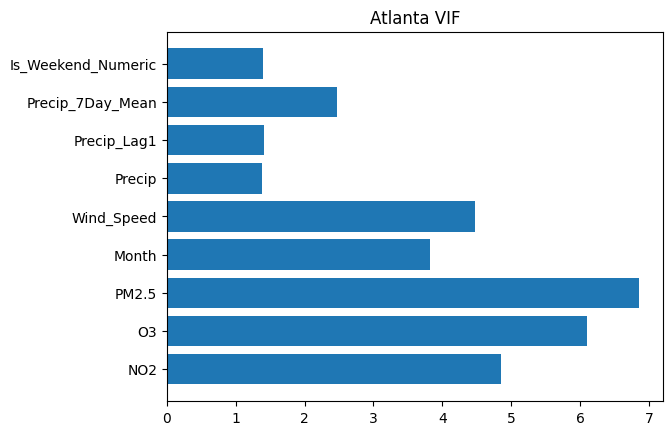

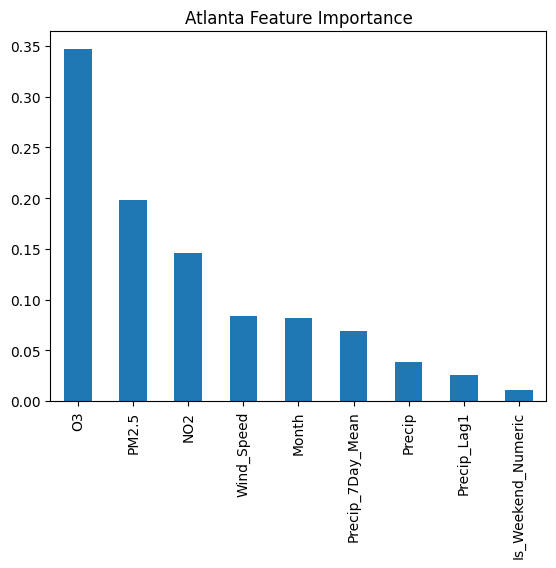


Final selected features: ['O3', 'PM2.5', 'NO2', 'Wind_Speed', 'Month', 'Precip_7Day_Mean', 'Precip', 'Precip_Lag1']

--- Linear Regression ---


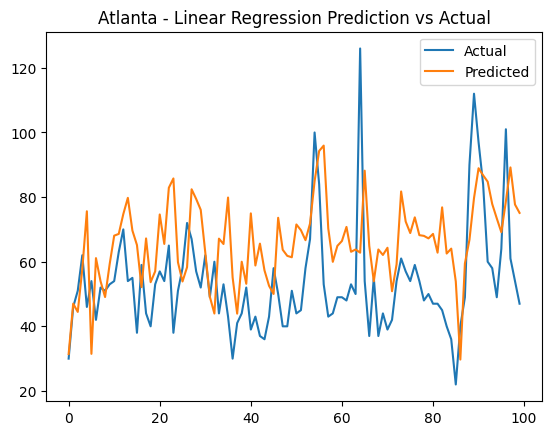

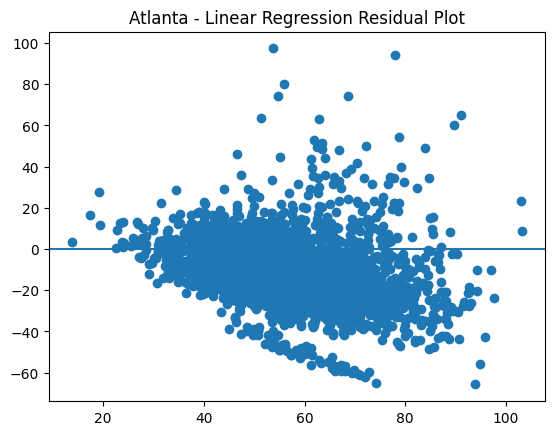


--- Decision Tree ---
Best Params: {'max_depth': 5}
CV Score: 0.21230991876978692


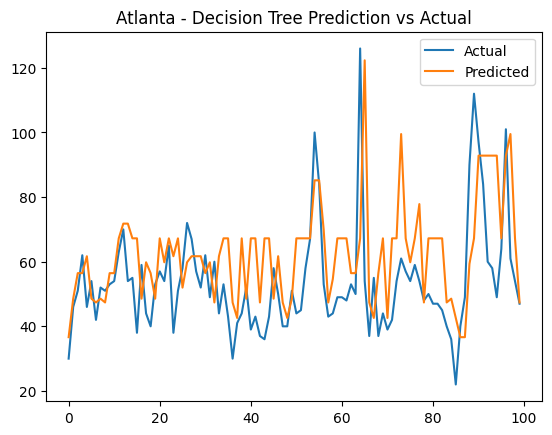

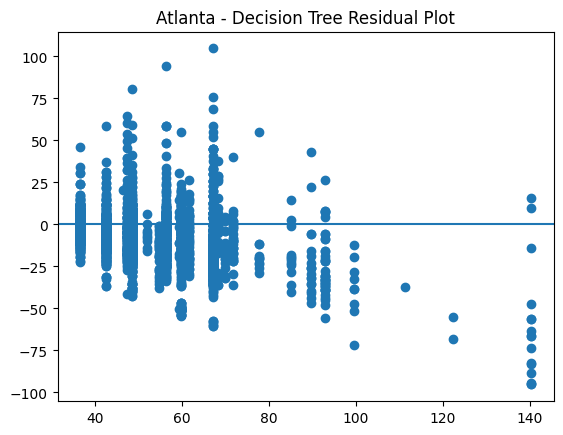


--- Random Forest ---
Best Params: {'max_depth': 5, 'n_estimators': 50}
CV Score: 0.30082815837037996


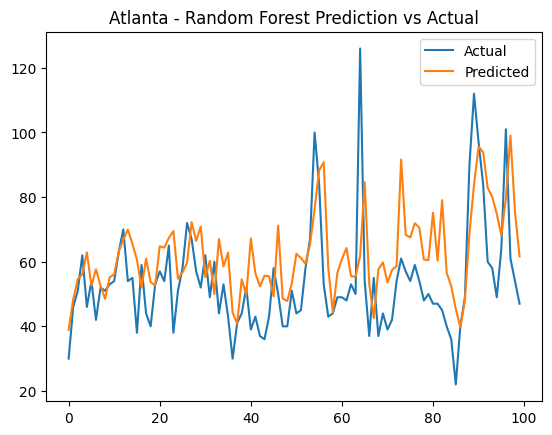

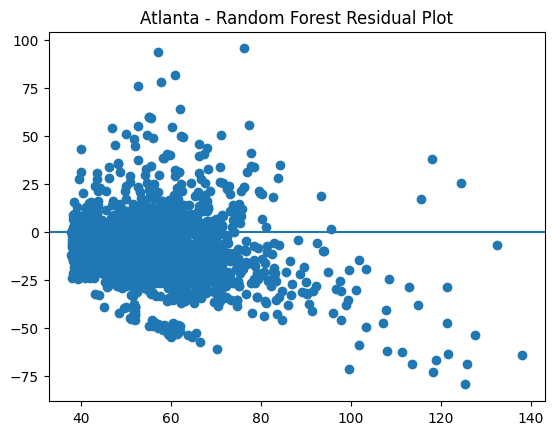


--- KNN ---
Best Params: {'model__n_neighbors': 7}
CV Score: 0.20729443664010744


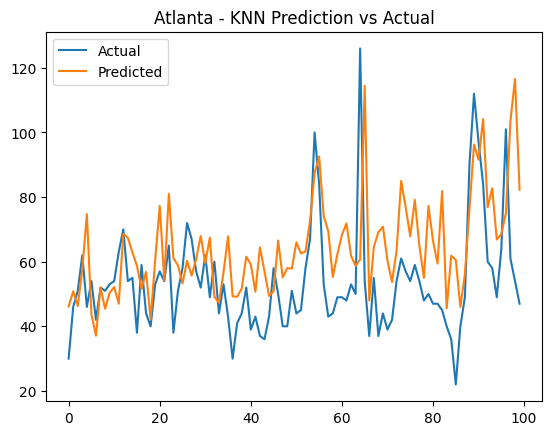

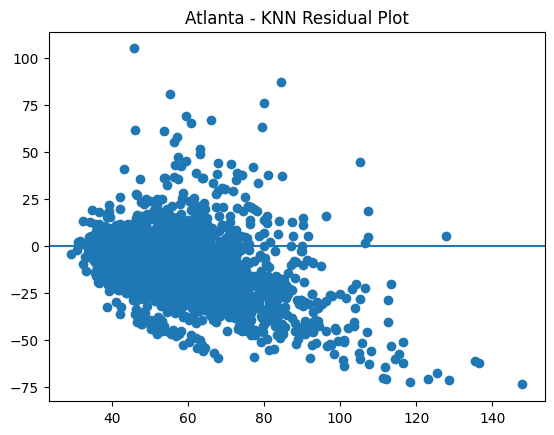


===== Los Angeles =====
Dropping non-numeric columns: Index(['AQI_Class', 'Season', 'Is_Weekend'], dtype='str')

--- Baselines ---
Persistence R2: 0.5868282203409823
Persistence MAE: 17.562762304463945
Correlation selected: ['NO2', 'O3', 'PM2.5', 'AQI', 'Month', 'Wind_Speed', 'Precip', 'Temp', 'AQI_Lag1', 'AQI_7Day_Mean', 'Precip_Lag1', 'Precip_7Day_Mean', 'Day_of_Week']


/var/folders/_h/w49ngcjj3251yjmj0qs76q3w0000gp/T/ipykernel_13314/3627925198.py:107: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = X_train.select_dtypes(include='object').columns


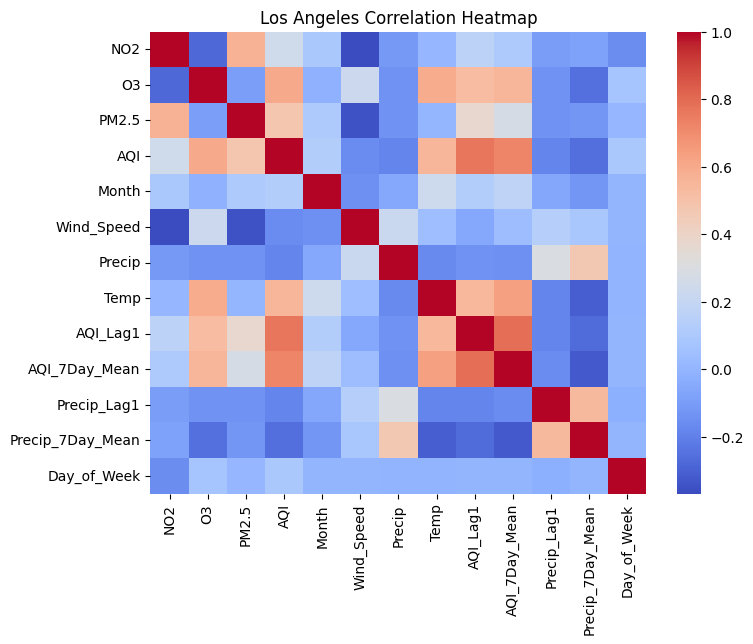

Dropping Temp (VIF=58.70)
Dropping AQI_7Day_Mean (VIF=28.69)
Dropping AQI (VIF=25.20)
Dropping O3 (VIF=14.66)


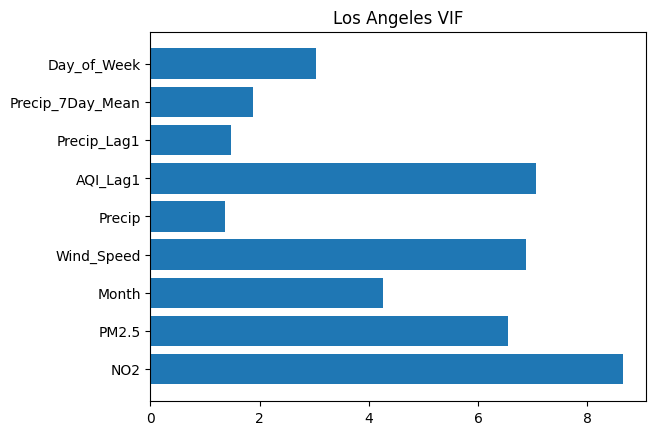

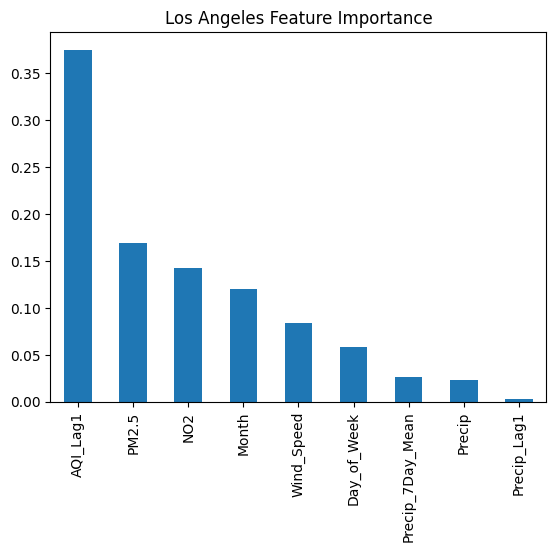


Final selected features: ['AQI_Lag1', 'PM2.5', 'NO2', 'Month', 'Wind_Speed', 'Day_of_Week', 'Precip_7Day_Mean', 'Precip']

--- Linear Regression ---


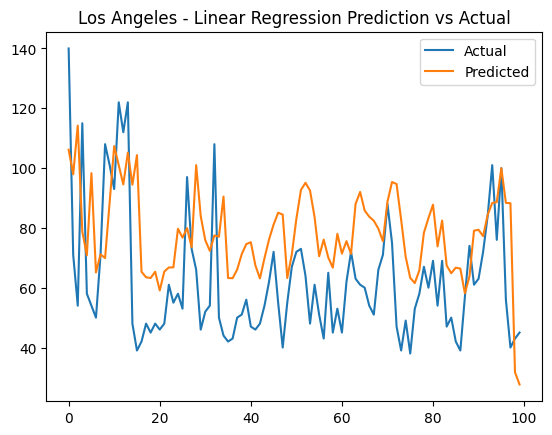

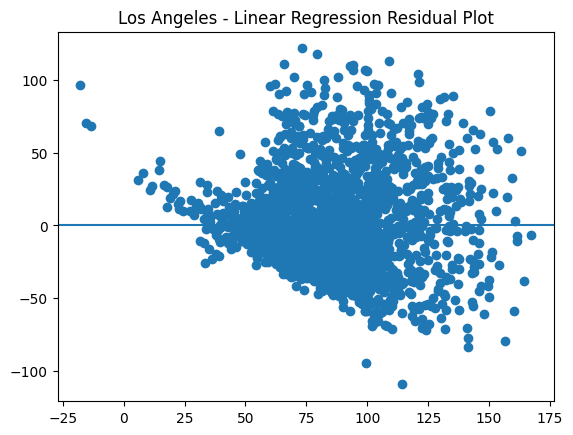


--- Decision Tree ---
Best Params: {'max_depth': 5}
CV Score: 0.3612216422956367


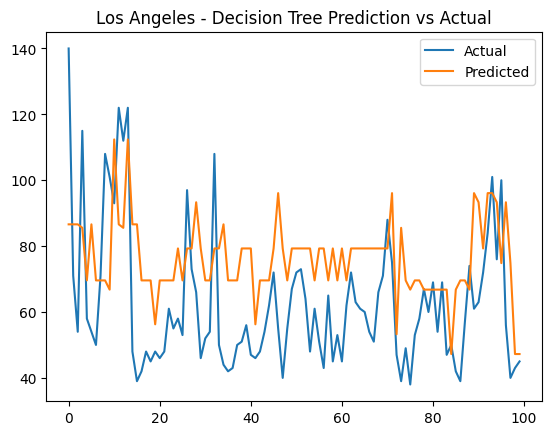

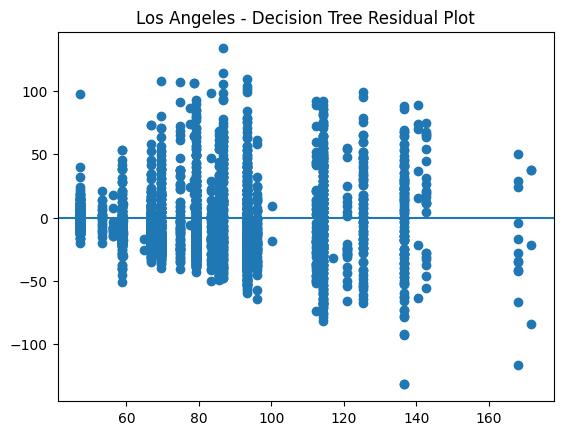


--- Random Forest ---
Best Params: {'max_depth': 10, 'n_estimators': 100}
CV Score: 0.4670802461005093


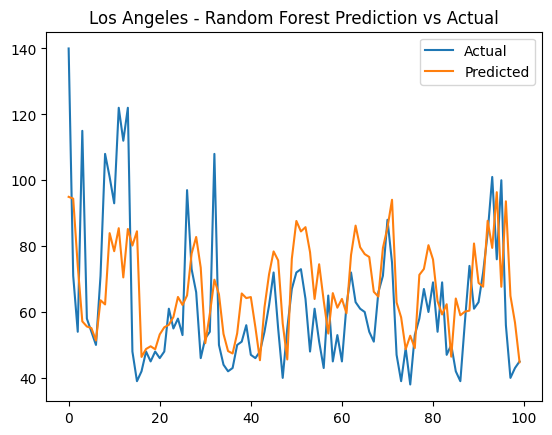

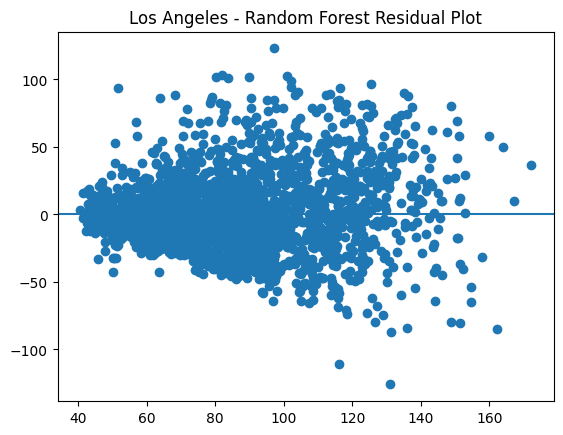


--- KNN ---
Best Params: {'model__n_neighbors': 7}
CV Score: 0.40566621738232894


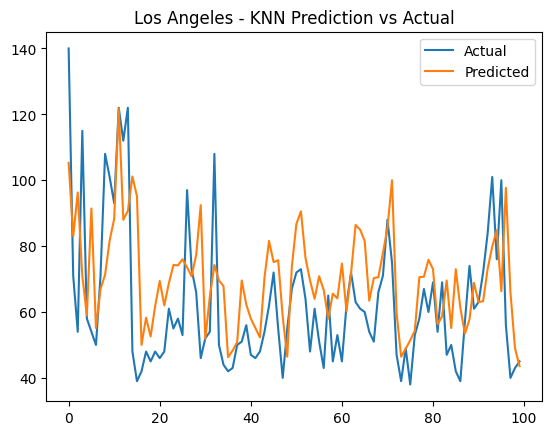

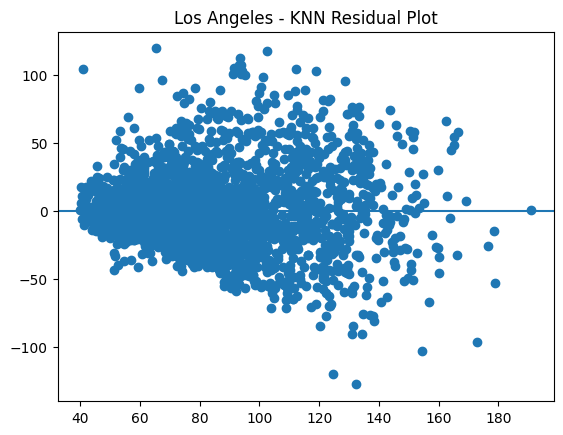


===== FINAL RESULTS =====
          City                   Model        R2        MAE
4  Los Angeles  Baseline (Persistence)  0.586828  17.562762
2  Los Angeles           Random Forest  0.517239  19.407208
3  Los Angeles                     KNN  0.464003  20.765193
1  Los Angeles           Decision Tree  0.411346  22.327096
0  Los Angeles       Linear Regression  0.383744  23.069733
4      Atlanta  Baseline (Persistence)  0.211542  10.790984
2      Atlanta           Random Forest -0.031612  13.593786
1      Atlanta           Decision Tree -0.152585  14.213847
0      Atlanta       Linear Regression -0.205572  15.454931
3      Atlanta                     KNN -0.316299  15.567171


In [53]:
df_atl = df[df["City"] == "Atlanta"].copy()
df_la = df[df["City"] == "Los Angeles"].copy()

results_atl = run_pipeline(df_atl, "Atlanta")
results_la = run_pipeline(df_la, "Los Angeles")

final_results = pd.concat([results_atl, results_la])

print("\n===== FINAL RESULTS =====")
print(final_results.sort_values(by="R2", ascending=False))

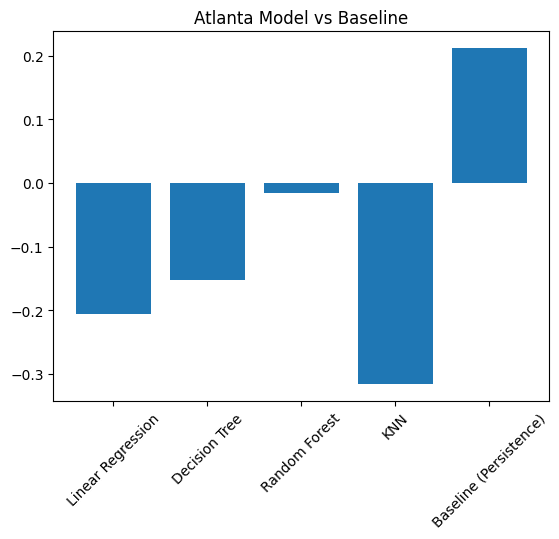

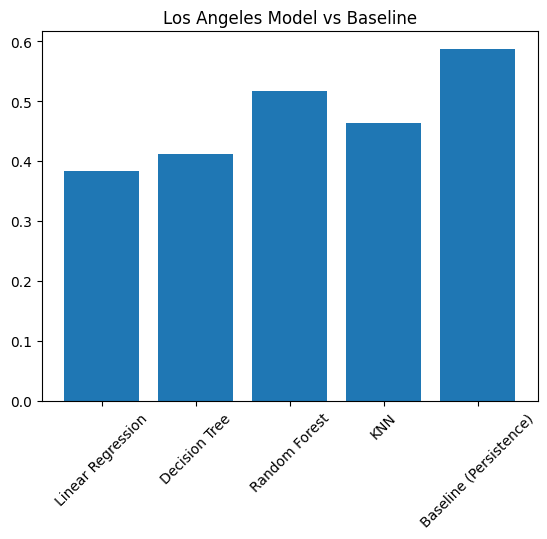

In [51]:
for city in final_results["City"].unique():
    df_city = final_results[final_results["City"] == city]

    plt.figure()
    plt.bar(df_city["Model"], df_city["R2"])
    plt.title(f"{city} Model vs Baseline")
    plt.xticks(rotation=45)
    plt.show()

A unified feature set was used across all models to ensure a fair comparison of model performance.

Future work could explore model-specific feature selection to further optimize performance.